<a href="https://colab.research.google.com/github/qanqanqan/gigachat_tutorials/blob/simple_agent_tutorial/first_agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Создай своего первого ИИ-агента

**Автор:** [Сергей Тращенков](https://t.me/gigatrash) (команда GigaChain)

Блокнот мастер-класса доступен по QR-коду:


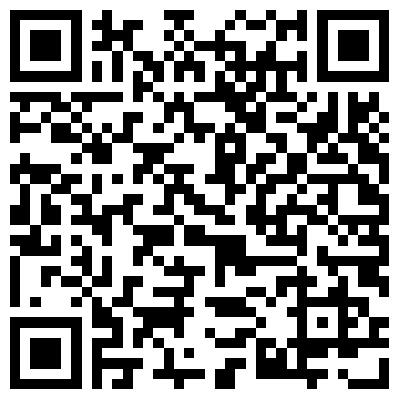



## О чем наш мастер-класс?



**2025 год объявлен годом агентных ИИ**

Gartner (международная исследовательская и консалтинговая компания в области ИТ) в своей публикации [«Top Strategic Technology Trends 2025»](https://www.gartner.com/en/articles/top-technology-trends-2025) на первое место ставит *Agentic AI* — системы, которые планируют шаги и **действуют** для достижения цели пользователя. Эту повестку подхватили компании по всему миру. Почему так и в чем же суть?

**LLM стали массовыми**

[По словам Сэма Альтмана](https://techcrunch.com/2025/10/06/sam-altman-says-chatgpt-has-hit-800m-weekly-active-users/), главы OpenAI, к октябрю 2025 у ChatGPT — около **800 млн пользователей в неделю**. [По данным «Российской газеты»](https://rg.ru/2025/05/29/rossiiane-osvoili-iskusstvennyj-intellekt-dolia-polzovatelej-ii-dostigla-392.html), доля пользователей ИИ в нашей стране достигла 39,2%, а регулярных — 17,3%; похожие тренды фиксируют и [другие опросы](https://www.cnews.ru/news/line/2025-06-25_kazhdyj_vtoroj_rossiyanin).

Независимо от конкретных платформ, регулярное использование генеративного ИИ растёт: [в отчёте Reuters Institute 2025](https://reutersinstitute.politics.ox.ac.uk/sites/default/files/2025-10/Gen_AI_and_News_Report_2025.pdf) доля людей, применяющих ИИ **еженедельно для получения информации**, выросла с 11% до 24%.

**Проблемы LLM**

Классические LLM (Large Language Models - большие языковые модели) умны, но отрезаны от реального мира и склонны к [галлюцинациям](https://openai.com/index/why-language-models-hallucinate/) — это фиксируют [исследования](https://www.ox.ac.uk/news/2024-06-20-major-research-hallucinating-generative-models-advances-reliability-artificial). Это значит, что сами по себе LLM не знают о событиях последнего времени, а еще способны выдумывать правдоподобные факты, которые не имеют место в реальности.

**От ассистента к агенту**

Чтобы преодолеть эти проблемы, модели обучили отвечать особым структурированным образом. Это позволило генерировать команды и вызовы инструментов. Благодаря этому можно искать в интернете, читать файлы, обращаться к API, писать и запускать код. Так появились ИИ-агенты.    

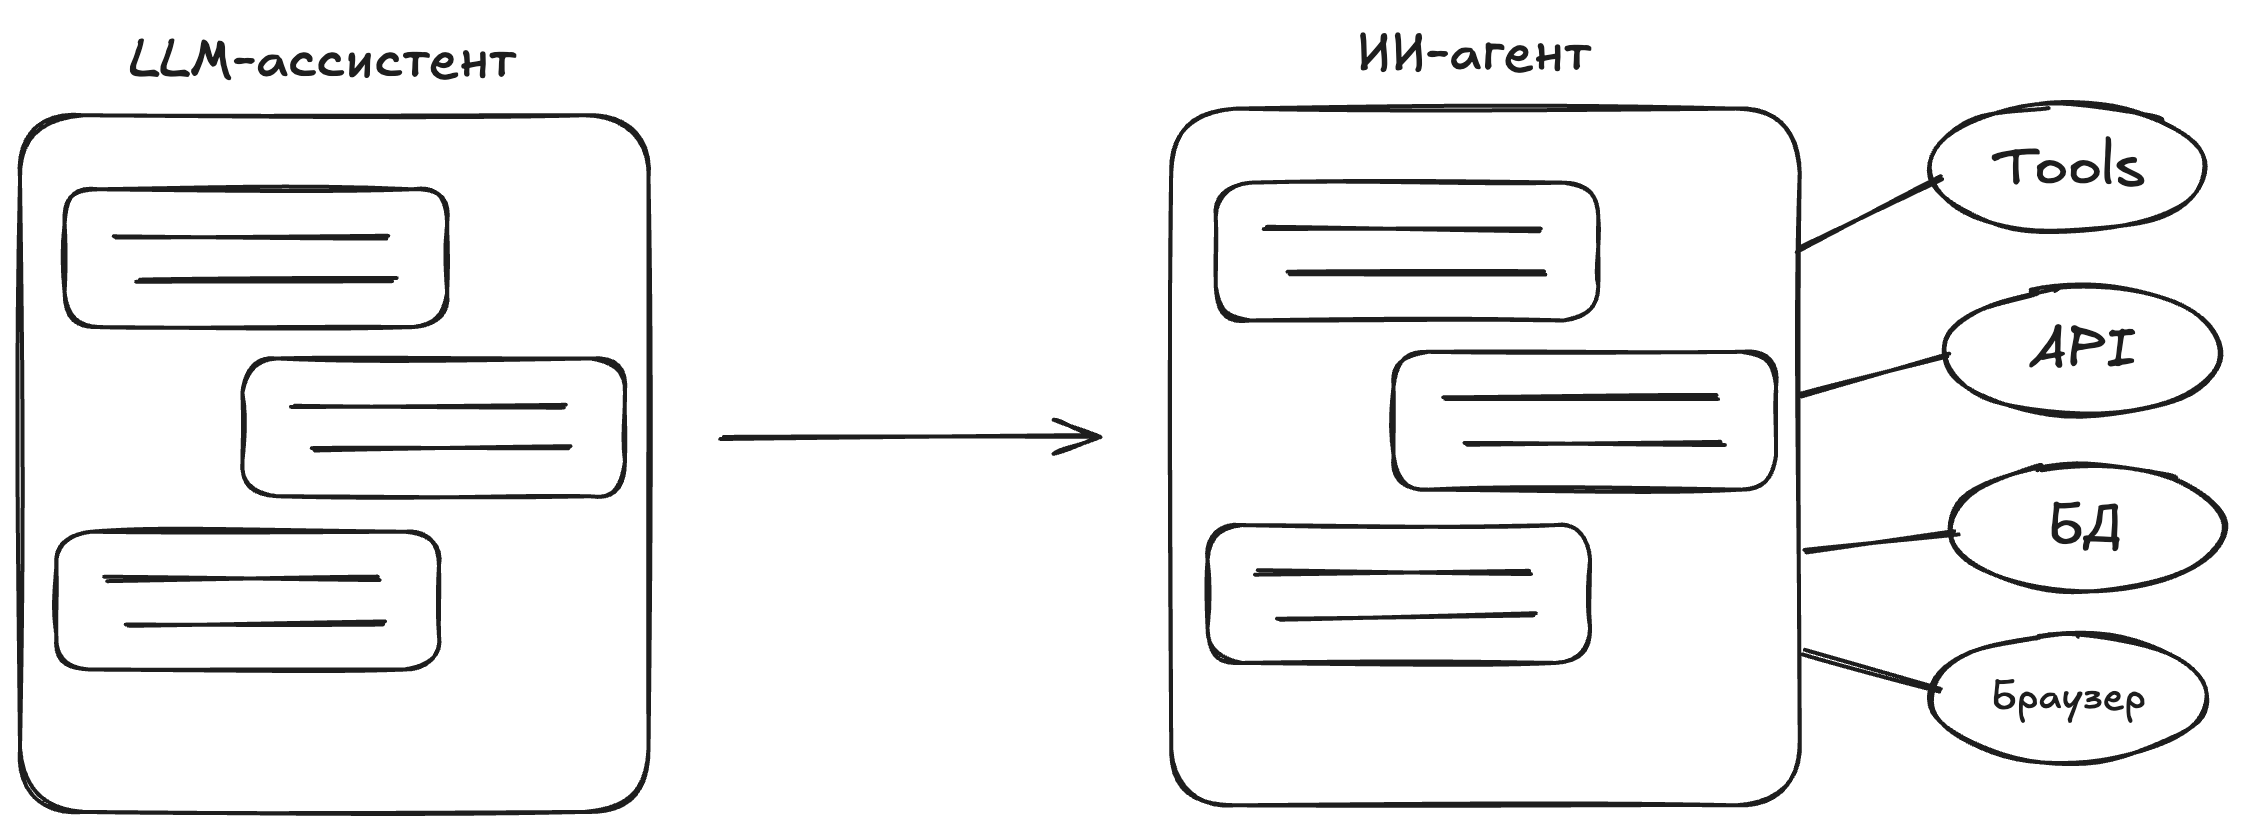

**Что сделаем сегодня?**

На практике соберем простого агента на Python с **GigaChat API**, добавим инструменты, а затем переделаем его под стандарт [**Model Context Protocol**](https://modelcontextprotocol.io/specification/latest), позволяющего унифицировать работу с агентами.

## Установка необходимых библиотек
Для работы нашего кода, необходимо установить ряд библиотек. Перечень библиотек составлен из расчета на запуск в среде Google Colabaratory, где уже предустановлено большое количество библиотек.

Если вы будете запускать код в другой среде, возможно потребуется установка дополнительных библиотек.  

In [ ]:
!pip install -q langchain-gigachat rich langchain==1.0.0a9

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.4/155.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.6/207.6 kB 7.5 MB/s eta 0:00:00


Мы установили:
- `langchain-gigachat` - библиотека для взаимодействия с GigaChat API и интеграции с фреймворками LangChain и LangGraph
- `langchain` - фреймворк для разработки ИИ-агентов и LLM-приложений
- `rich` - библиотека для наглядного форматирования вывода в терминале

### Почему мы используем LangChain и LangGraph?
Чтобы не писать код агента с нуля, удобно прибегать к готовым фреймворкам.

Самым «живым» стеком для LLM-приложений является пара фреймворков [LangChain](https://github.com/langchain-ai/langchain)/[LangGraph](https://github.com/langchain-ai/langgraph): у них больше всех звезд на GitHub, активное сообщество и много реальных [кейсов промышленного внедрения](https://www.langchain.com/built-with-langgraph).

## Получение API-ключа для GigaChat
Чтобы получить доступ к GigaChat API, нужно зарегистрироваться в [личном кабинете Studio](https://developers.sber.ru/studio/login), создать проект GigaChat API и сгенерировать ключ авторизации. Подробности смотрите в [документации](https://developers.sber.ru/docs/ru/gigachat/quickstart/ind-create-project).

Также в личном кабинете можно отслеживать потребление токенов.

В рамках этого мастер-класса в качестве среды разработки мы используем Google Colabaratory. Эта среда позволяет безопасно хранить ключи доступа в специальном разделе "Секреты" (панель слева).

Загрузим ключ авторизации для GigaChat API из Секретов Google Colabaratory:

In [ ]:
from google.colab import userdata
auth = userdata.get('SBER_AUTH')

## Создаем диалогового ассистента на GigaChat
### Одиночный запрос к модели
Для начала рассмотрим, как происходит отправка одиночного запроса к LLM и получение ответа от неё. Понимание этого позволит дальше встроить обращения к LLM в приложения по обработке данных и перейти к более сложным сценариям, например, к диалоговому ассистенту.

В коде ниже выполним следующие действия:
* создадим клиент `GigaChat`, используя авторизационный ключ `auth`
* вызовем модель с помощью метода `invoke()` с текстом запроса;
* выведем на экран объект `AIMessage` **целиком**, чтобы увидеть и текст ответа, и метаданные (например, `token_usage`, `model_name`, `finish_reason`, `x_headers`)




In [ ]:
from langchain_gigachat import GigaChat
from rich.console import Console

console = Console()
llm = GigaChat(credentials=auth, verify_ssl_certs=False)

response = llm.invoke("Привет! Объясни простыми словами, что такое искусственный интеллект.")
console.print(response)


AIMessage(
    content='Искусственный интеллект (ИИ) — это когда компьютер или программа начинают думать, принимать решения и 
действовать примерно так же, как человек: понимают слова, распознают предметы, решают задачи, общаются, учатся 
новому, адаптируются к разным ситуациям. \n\nНапример, умный голосовой помощник вроде Алисы от Яндекса, который 
помогает искать информацию, отвечать на вопросы и даже шутит, или автопилот автомобиля Tesla, который сам ведет 
машину по дороге — всё это проявления ИИ. Просто такие программы созданы людьми, чтобы помогать нам быстрее и 
удобнее решать разные повседневные задачи.',
    additional_kwargs={},
    response_metadata={
        'token_usage': {
            'prompt_tokens': 24,
            'completion_tokens': 119,
            'total_tokens': 143,
            'precached_prompt_tokens': 2
        },
        'model_name': 'GigaChat:2.0.28.2',
        'x_headers': {
            'x-request-id': '7a26a2bd-6d66-42b1-9326-7905f08a5b44',
            'x-session-id': 'd772a108-9874-4917-af28-184da7545a5e',
            'x-client-id': None
        },
        'finish_reason': 'stop'
    },
    id='7a26a2bd-6d66-42b1-9326-7905f08a5b44',
    usage_metadata={
        'output_tokens': 119,
        'input_tokens': 24,
        'total_tokens': 143,
        'input_token_details': {'cache_read': 2}
    }
)

Ответ модели во фреймворке LangChain представляется в виде объекта класса `AIMessage`. Он содержит сам текст ответа и метаданные о запросе/ответе.

* `content` — текст, который сгенерировала модель; именно его обычно показывают пользователю.
* `additional_kwargs` — доп. поля для особых режимов (например, tool/function calls); в простом кейсе пусто.
* `response_metadata` — метаданные от провайдера/клиента модели:

  * `token_usage`:

    * `prompt_tokens` — токены входа (промпта);
    * `completion_tokens` — токены в ответе;
    * `total_tokens` — сумма входа и ответа;
    * `precached_prompt_tokens` — часть входных токенов пришла из кэша (prompt caching).
  * `model_name` — точное имя/версия модели.
  * `x_headers`:

    * `x-request-id` — уникальный ID запроса (полезно для трассировки);
    * `x-session-id` — ID сессии (связывает сообщения одного диалога);
    * `x-client-id` — идентификатор клиента (часто `None` в демо).
  * `finish_reason` — причина остановки генерации (типично: `stop` — штатно; `length` — достигнут лимит длины).
* `id` — идентификатор самого сообщения (UUID на стороне LangChain).
* `usage_metadata` — сводные счётчики от LangChain:

  * `input_tokens` — входные токены;
  * `output_tokens` — токены ответа;
  * `total_tokens` — сумма;
  * `input_token_details`:

    * `cache_read` — сколько входных токенов прочитано из кэша (соотносится с `precached_prompt_tokens`).



### Диалоговый режим с историей сообщений

Перейдем от одиночных запросов к **диалогу** с памятью контекста.

* Используем `GigaChat` и классы `SystemMessage`/`HumanMessage`/`AIMessage` из LangChain: история (`chat_history`) хранит все реплики диалога с ролями.
* Ввод пользователя читается в цикле (`input(...)`). Пустая строка или `exit/quit` — выход.
* На каждый ход:

  * добавляем в `chat_history` сообщение пользователя: `HumanMessage(content=...)`
  * вызываем модель **на всей истории**: `llm.invoke(chat_history)` — модель видит предыдущие реплики и отвечает с учётом контекста
  * добавляем ответ модели в историю: `AIMessage(content=response.content)`
  * выводим текст ответа на экран

* Важно: чем длиннее диалог, тем больше токенов уходит на передачу истории; поэтому в реальных LLM-приложениях прибегают к суммаризации/обрезке истории или или иным техникам управления контекстом.

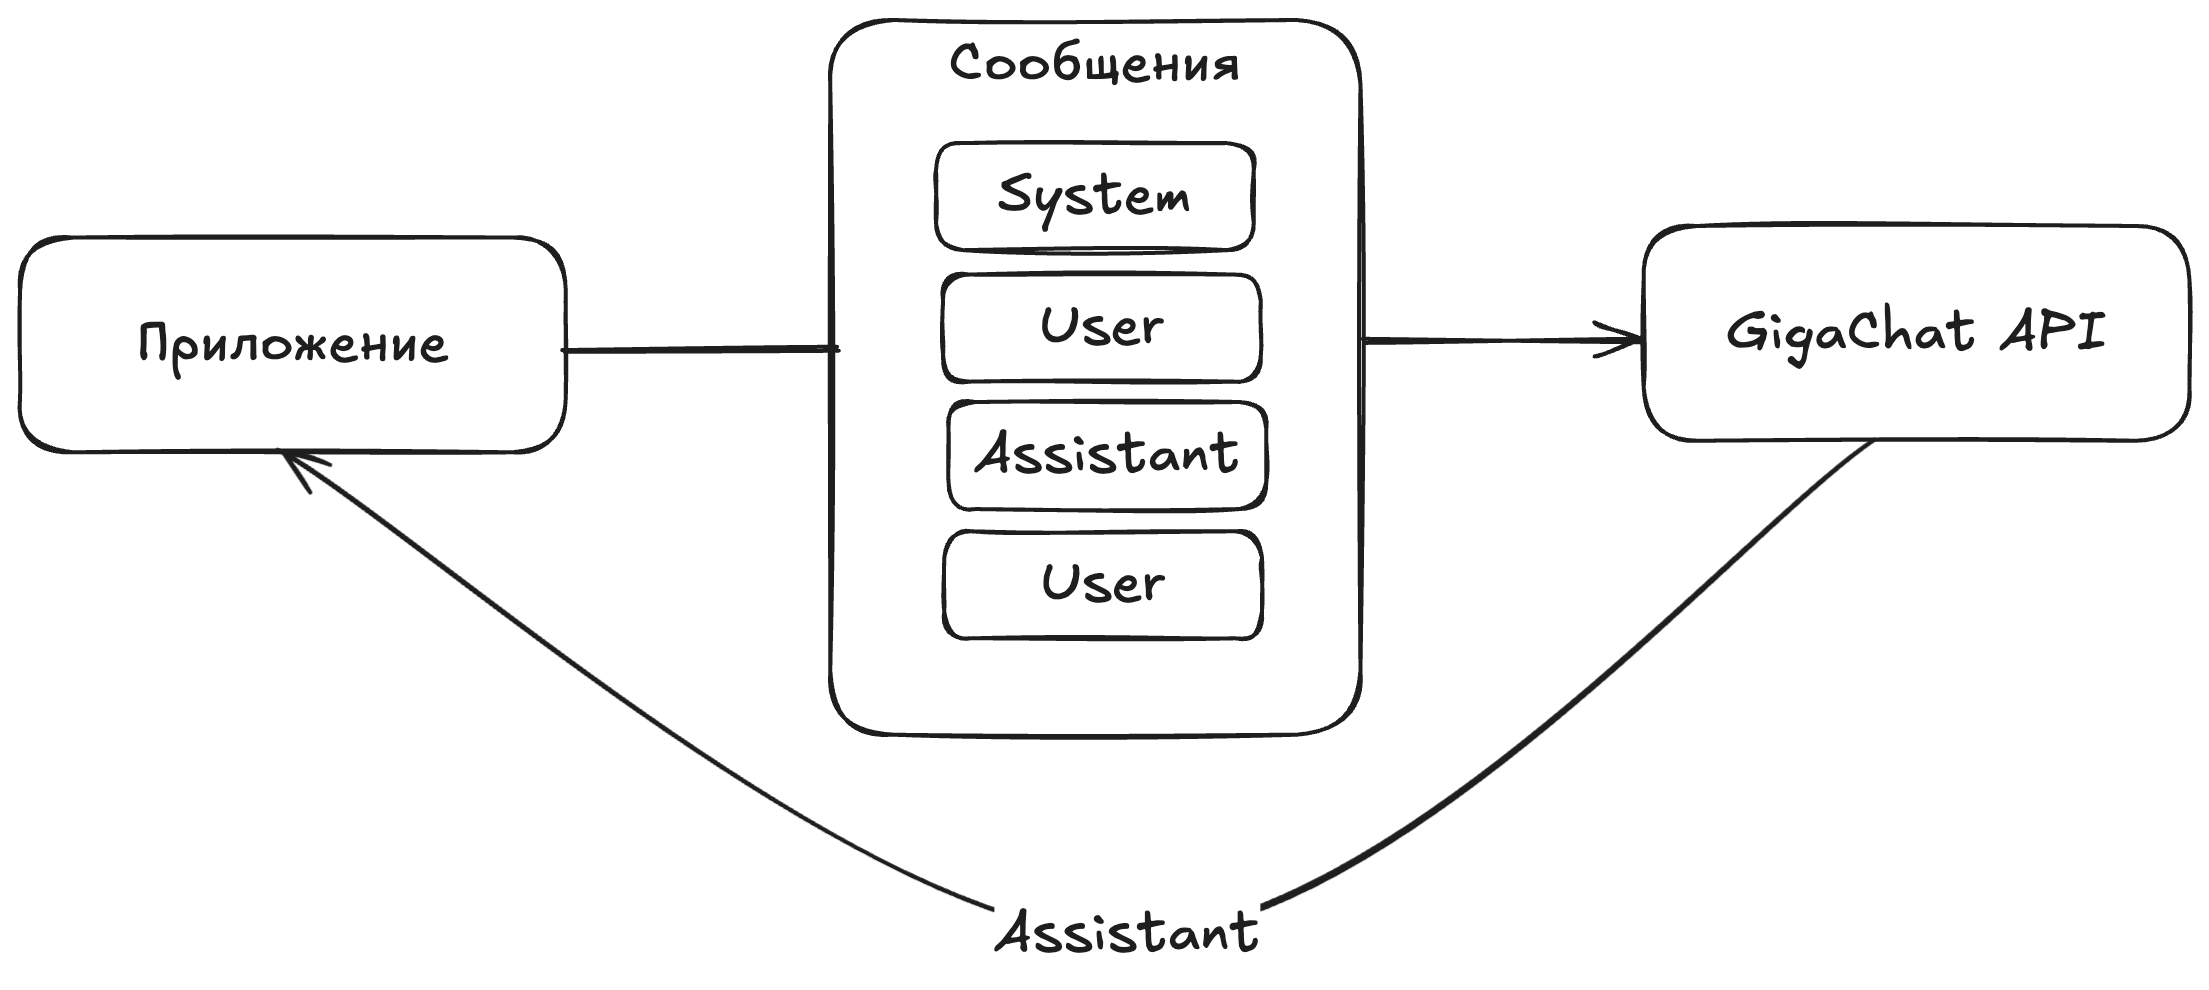


In [ ]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_gigachat import GigaChat

llm = GigaChat(credentials=auth, verify_ssl_certs=False)

# Создадим системный промпт модели: текст с описанием тона, стиля и правил
# Добавим его в переменную, которая будет хранить историю сообщений

chat_history = [
    SystemMessage(content=(
        "Ты — дружелюбный ассистент. Отвечай кратко и по делу. "
        "Если не уверен/не знаешь, скажи об этом."
    ))
]

print("💬 Чат с GigaChat запущен.")
print("Введите сообщение и нажмите Enter.")
print("Чтобы выйти — введите пустую строку или команду exit/quit.\n")

while True:
    user_text = input("👤 Вы: ").strip()
    if user_text.lower() in ["exit", "quit", ""]:
        print("✅ Чат завершён.")
        break

    chat_history.append(HumanMessage(content=user_text))
    response = llm.invoke(chat_history)
    chat_history.append(AIMessage(content=response.content))

    print("🤖 GigaChat:", response.content, "\n")


💬 Чат с GigaChat запущен.
Введите сообщение и нажмите Enter.
Чтобы выйти — введите пустую строку или команду exit/quit.

👤 Вы: Привет, меня зовут Сергей
🤖 GigaChat: Привет, Сергей! Как твои дела? 

👤 Вы: Как меня зовут?
🤖 GigaChat: Тебя зовут Сергей. 

👤 Вы: какая сейчас погода?
🤖 GigaChat: У меня нет данных о текущей погоде. Лучше посмотреть это в приложении погоды или на сайте метеослужбы. 

👤 Вы: 
✅ Чат завершён.


Попробуйте после мастер-класса поэкспериментировать самостоятельно с разными вариантами системных промптов:

```
Ты — преподаватель, объясняющий сложные вещи простыми словами. Строй ответ по схеме: идея в одном-двух предложениях → короткий бытовой пример → один термин с пояснением. Не используй код, если о нём не попросили.
```

```
Ты — технический ассистент. Формат каждого ответа:
1) Контекст (1–2 предложения);
2) Решение (шаги списком, максимум 5 пунктов);
3) Пример (1–2 строки без кода, если код не запрошен).
Не раскрывай внутренние шаги модели.
```
```
Ты — ассистент, который даёт ответ и в конце добавляет строку «Итого: …» с одним выводом. Не используй код и не описывай внутренние процессы. Пиши коротко.
```


Чтобы управлять диалогом, чат-модели получают **список сообщений с ролями** — каждая роль имеет свое назначение в контексте:

* **system** — системные инструкции: тон, стиль, формат и ограничения ответа; обычно ставится в начале и действует на весь диалог
* **user** — запрос или данные от пользователя, на которые модель отвечает с учётом `system` и истории
* **assistant** — ответ модели; в агентных сценариях может содержать вызовы инструментов (tool calls); предыдущие ответы остаются в истории для контекста
* **tool** — результат внешнего инструмента, связанный с вызовом через `tool_call_id`; не для пользователя напрямую, а для следующего шага модели

В терминах LangChain роли [соответствуют классам](https://docs.langchain.com/oss/python/langchain/messages): `SystemMessage` (system), `HumanMessage` (user), `AIMessage` (assistant), `ToolMessage` (tool).


## Переход от диалогового ассистента к агенту

В реализованном нами диалоговом ассистенте модель при формировании ответа использует только контекст системного промпта и пользовательских сообщений, а также свои общие (ограниченные) знания. В историю диалога попадают лишь сообщения ролей `system`, `user` и `assistant`. Поэтому здесь **нет** `AIMessage` с `tool_calls` и **нет** `ToolMessage` — такие сообщения появляются уже в **агентной** архитектуре.

Дальше мы перейдём к агенту: модель сможет инициировать вызовы инструментов (tool calls), результаты будут приходить как `ToolMessage` и возвращаться в контекст для продолжения ответа. В качестве инструментов подключим функции на Python, чтобы обогащать диалог новыми фактическими данными.

### Реализация инструментов и их привязка к объекту GigaChat

Подготовим инструменты и модель для создания агента.

Для этого объявим объявим Python-функции, [обернув их в специальный декоратор](https://docs.langchain.com/oss/python/langchain/tools) `@tool`.

Пусть у нас будет два инструмента:

* `get_weather(city)` — берёт текущее состояние погоды из публичного API `wttr.in` и возвращает короткую строку (подробнее см. [репозиторий](https://github.com/chubin/wttr.in));
* `get_air_quality(city)` — находит координаты города через Open-Meteo Geocoding и получает PM2.5/PM10 из Open-Meteо Air Quality.
  
Оба инструмента работают без ключей, синхронно через библиотеку `requests`, с таймаутами и простой обработкой ошибок (`"Ошибка: …"`).

Далее инициализируем `GigaChat` и собираем список `tools`, куда помещаем наши инструменты.

#### Несколько слов о параметрах PM2.5/PM10

Качество воздуха обычно оценивают по концентрациям взвешенных частиц (PM) и некоторых газов (озон O₃, диоксид азота NO₂, диоксид серы SO₂, угарный газ CO). Чтобы упростить, будем запрашивать только концентрацию частиц. Для частиц чаще всего смотрят PM2.5 (очень мелкая пыль до 2,5 мкм) и PM10 (до 10 мкм). Единицы измерения — мкг/м³: чем меньше число, тем чище воздух. Мы будем получать почасовые значения, которые можно принять за мгновенные.

Можете самостоятельно поэкспериментировать с созданием инструментов определения качества воздуха, подобрав другие параметры через запросы к [Open-Meteо](https://open-meteo.com/en/docs/air-quality-api).  

In [ ]:
from langchain.tools import tool
from langchain_gigachat import GigaChat
import requests

# --- Инструменты ---
@tool
def get_weather(city: str) -> str:
    """Получение текущей температуры через API wttr.in.
    Args:
        city (str): Название города (англ.)
    Returns:
        str: 'ясно, +20 °C' или сообщение об ошибке
    """
    url = f"https://wttr.in/{city}?format=j1"
    try:
        data = requests.get(url, timeout=60).json()
        temp_c = data["current_condition"][0]["temp_C"]
        desc   = data["current_condition"][0]["weatherDesc"][0]["value"]
        return f"{desc.lower()}, {temp_c} °C"
    except Exception as e:
        return f"Ошибка: {e}"


@tool
def get_air_quality(city: str) -> str:
    """Возвращает PM2.5 / PM10 для заданного города.
    Args:
        city (str): Название города (англ., с большой буквы)
    Returns:
        str: 'PM2.5 = …, PM10 = …' или сообщение об ошибке
    """
    try:
        # Определяем координаты города
        geo_url = f"https://geocoding-api.open-meteo.com/v1/search?name={city}&count=1&language=en"
        geo = requests.get(geo_url, timeout=60).json()
        if not geo.get("results"):
            return "Город не найден"

        lat, lon = geo["results"][0]["latitude"], geo["results"][0]["longitude"]

        # Качество воздуха
        aq_url = (
            "https://air-quality-api.open-meteo.com/v1/air-quality"
            f"?latitude={lat}&longitude={lon}&hourly=pm10,pm2_5&forecast_days=1"
        )
        aq = requests.get(aq_url, timeout=60).json()
        pm25, pm10 = aq["hourly"]["pm2_5"][0], aq["hourly"]["pm10"][0]
        return f"PM2.5 = {pm25} µg/m³, PM10 = {pm10} µg/m³"
    except Exception as e:
        return f"Ошибка: {e}"


# --- LLM ---
llm = GigaChat(credentials=auth, verify_ssl_certs=False)

tools = [get_weather, get_air_quality]

print("✅ Тулы и LLM готовы")


✅ Тулы и LLM готовы


Обратите внимание на описание функций в виде `docstring`. Если в обычных функциях эти описания составляются для разработчика и не влияют на работу кода, то с агентами это не так. Дело в том, что описание функции — это то, что модель видит в контексте: по нему она понимает назначение, ограничения и формат аргументов/ответа. Делайте `docstring` лаконичным и предметным. Чем более понятным будет описание, тем лучше будет работать ваш агент.



In [ ]:
llm_with_tools = llm.bind_tools(tools)
console.rule("[bold]Конфигурация вызова с tools")
console.print(llm_with_tools)

question = "Какая сейчас погода в Нижнем Новгороде?"
resp = llm_with_tools.invoke([HumanMessage(content=question)])
console.rule("[bold]Ответ модели (tool_call)")
console.print(resp)

─────────────────────────────────────────── Конфигурация вызова с tools ───────────────────────────────────────────

RunnableBinding(
    bound=GigaChat(
        credentials='ODM5YjVhOWItOTFmYi00MjdiLWJhOGMtOGU3NDVmOWNjZDg0OmJmZDMxMDIzLWE4MmYtNDZlYi1iN2MzLTc2NDFlMTdlM2
NmOA==',
        verify_ssl_certs=False
    ),
    kwargs={
        'tools': [
            {
                'type': 'function',
                'function': {
                    'name': 'get_weather',
                    'description': "Получение текущей температуры через API wttr.in.\n    Args:\n        city 
(str): Название города (англ.)\n    Returns:\n        str: 'ясно, +20 °C' или сообщение об ошибке",
                    'parameters': {
                        'properties': {'city': {'type': 'string', 'description': ''}},
                        'required': ['city'],
                        'type': 'object'
                    },
                    'return_parameters': None,
                    'few_shot_examples': None
                }
            },
            {
                'type': 'function',
                'function': {
                    'name': 'get_air_quality',
                    'description': "Возвращает PM2.5 / PM10 для заданного города.\n    Args:\n        city (str): 
Название города (англ., с большой буквы)\n    Returns:\n        str: 'PM2.5 = …, PM10 = …' или сообщение об 
ошибке",
                    'parameters': {
                        'properties': {'city': {'type': 'string', 'description': ''}},
                        'required': ['city'],
                        'type': 'object'
                    },
                    'return_parameters': None,
                    'few_shot_examples': None
                }
            }
        ]
    },
    config={},
    config_factories=[]
)

──────────────────────────────────────────── Ответ модели (tool_call) ─────────────────────────────────────────────

AIMessage(
    content='',
    additional_kwargs={
        'function_call': {'name': 'get_weather', 'arguments': {'city': 'Нижний Новгород'}},
        'functions_state_id': '0199cd93-95e0-7263-81bb-a8326bfb9aa7'
    },
    response_metadata={
        'token_usage': {
            'prompt_tokens': 189,
            'completion_tokens': 25,
            'total_tokens': 214,
            'precached_prompt_tokens': 0
        },
        'model_name': 'GigaChat:2.0.28.2',
        'x_headers': {
            'x-request-id': '292f74d8-8a53-48df-acfc-890dcfa84e6f',
            'x-session-id': '666feb16-7745-4275-8719-304473d6643b',
            'x-client-id': None
        },
        'finish_reason': 'function_call'
    },
    id='292f74d8-8a53-48df-acfc-890dcfa84e6f',
    tool_calls=[
        {
            'name': 'get_weather',
            'args': {'city': 'Нижний Новгород'},
            'id': 'ceff481d-fe9c-4908-a3d2-3ff9e61de0db',
            'type': 'tool_call'
        }
    ],
    usage_metadata={
        'output_tokens': 25,
        'input_tokens': 189,
        'total_tokens': 214,
        'input_token_details': {'cache_read': 0}
    }
)

 В ячейке кода выше мы видим объект `RunnableBinding`. В LangChain различные абстрации `Runnable` служат в качестве интерфейсов для объектов, которые можно запустить. Это могут быть модели, различные цепочки и т.д. При запуске `RunnableBinding` к запросу пользователя добавляются параметры из списка инструментов.


 Как видим, в `AIMessage()` поле `content` пусто, зато `finish_reason='function_call'`. Это  значит, что модель решила вызвать инструмент, а `tool_calls` показывает, какой именно инструмент и с какими аргументами нужно выполнить (здесь — `get_weather` с `city = "Нижний Новгород"`). В `response_metadata` — служебные метаданные (модель, токены, идентификаторы запроса/сессии), в `usage_metadata` — свод по токенам.

 Следующий шаг агентного цикла: выполнить вызов инструмента, вернуть результат как `ToolMessage`, после чего модель сформирует следующий `AIMessage` с новым запросом к инструментам или заполнит поле `content` уже с финальным текстовым ответом для пользователя.

Давайте далее посмотрим как агентный цикл выглядит на практике.

## Реализация простого ReAct-агента

В качестве агента мы возьмем простой вариант с максимальной свободой действий, который называют ReAct-агентом.

ReAct — это паттерн, в котором модель чередует размышления, действия и наблюдения, вызывая внешние инструменты для решения многошаговых задач. При этом модель сама определяет на каждом шаге, какое действие предпринять.

Для создания агента мы обернём наши абстрации в виде инструментов и клиента для обращения к GigaChat API, в готовую реализацию из фреймворка LangGraph — `create_agent` из `langchain.agents`.

Этот конструктор сразу собирает минимальный ReAct-цикл как граф состояний: подключает модель и инструменты, обрабатывает структурные `tool_calls/ToolMessage` и выполняет шаги, определенные моделью.

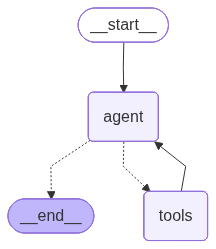

In [ ]:
from langchain.agents import create_agent

agent_no_memory = create_agent(llm, tools)
agent_no_memory

Представить агента в виде схемы можно как показано на диаграмме выше. Узел **agent** означает вызов модели, узел **tools** — выполнение подключённых инструментов; обратная стрелка означает, что после `ToolMessage` цикл повторяется, пока модель не вернёт `AIMessage` **без** `tool_calls` (финальный ответ).

Теперь запустим получившегося агента в интерактивном цикле: на каждом вводе агент сам решает, какие инструменты звать, а в мы увидим последовательность шагов (Human → AI/tool_calls → Tool → AI).


In [ ]:
print("💬 Агент без памяти. Пустая строка — выход.\n")

while True:
    user_text = input("👤 Вы: ").strip()
    if not user_text:
        print("✅ Диалог завершён.")
        break

    response = agent_no_memory.invoke({
        "messages": [{"role": "user", "content": user_text}]
    })

    print("🤖 Агент (без памяти):\n")
    for msg in response["messages"]:
        msg.pretty_print()
    print()


💬 Агент без памяти. Пустая строка — выход.

👤 Вы: Какая погода и состояние воздуха в Москве? Дай рекомендации
🤖 Агент (без памяти):

================================ Human Message =================================

Какая погода и состояние воздуха в Москве? Дай рекомендации
================================== Ai Message ==================================
Tool Calls:
  get_weather (52889e21-9818-45a7-967f-c8645de1b68c)
 Call ID: 52889e21-9818-45a7-967f-c8645de1b68c
  Args:
    city: Москва
================================= Tool Message =================================
Name: get_weather

light rain shower, 8 °C
================================== Ai Message ==================================
Tool Calls:
  get_air_quality (6f181a97-0afa-4545-8e64-0bad75d77343)
 Call ID: 6f181a97-0afa-4545-8e64-0bad75d77343
  Args:
    city: Москва
================================= Tool Message =================================
Name: get_air_quality

PM2.5 = 8.1 µg/m³, PM10 = 9.0 µg/m³
=====================

В примере выше по поведению агента мы видим, что общий контекст между сообщениями есть только в рамках выполнения отдельного пользовательского запроса. С новым запросом память "обнуляется". Чтобы исправить это, добавим к нашему агенту Checkpointer.   


### ReAct-агент с памятью

Checkpointer - это абстракция из библиотеки LangGraph, которая позволяет сохранять  состояние графа после каждого шага в рамках одного диалога (thread). При следующем вызове по тому же `thread_id` состояние автоматически подхватывается, и агент продолжает диалог с учётом контекста.

Чекпоинтеры бывают разные. `MemorySaver` — самый простой из них: он хранит состояния (их еще называют снимками) в оперативной памяти процесса, но есть и чекпоинтеры для работы с такими базами данных как PostgreSQL. Для демо мы используем `MemorySaver`.

Если нужно запустить новый диалог, следует указать другой `thread_id`.

In [ ]:
from langgraph.checkpoint.memory import MemorySaver
from langchain.agents import create_agent
memory = MemorySaver()
agent_with_memory = create_agent(llm, tools, checkpointer=memory)

print("💬 Агент с памятью. Пустая строка — выход.\n")

while True:
    user_text = input("👤 Вы: ").strip()
    if not user_text:
        print("✅ Диалог завершён.")
        break

    response = agent_with_memory.invoke(
        {"messages": [{"role": "user", "content": user_text}]},
        config={"configurable": {"thread_id": "demo1"}}  # общий ID диалога
    )

    print("🤖 Агент (с памятью):\n")
    for msg in response["messages"]:
        msg.pretty_print()
    print()


💬 Агент с памятью. Пустая строка — выход.

👤 Вы: Какая погода и воздух в Москве. Дай рекомендации
🤖 Агент (с памятью):

================================ Human Message =================================

Какая погода и воздух в Москве. Дай рекомендации
================================== Ai Message ==================================
Tool Calls:
  get_weather (f105b5a3-6335-40de-9d87-e976a0f810d7)
 Call ID: f105b5a3-6335-40de-9d87-e976a0f810d7
  Args:
    city: Москва
================================= Tool Message =================================
Name: get_weather

light rain shower, 8 °C
================================== Ai Message ==================================
Tool Calls:
  get_air_quality (de51e022-a995-49c0-b700-27e898b060e5)
 Call ID: de51e022-a995-49c0-b700-27e898b060e5
  Args:
    city: Москва
================================= Tool Message =================================
Name: get_air_quality

PM2.5 = 8.1 µg/m³, PM10 = 9.0 µg/m³
================================== Ai Message

Как видим по диалогу, агент теперь хранит общий контекст в рамках одного `thread_id`. Если хотите еще углубиться в вопросы управления памятью ReAct-агента, то посмотрите [документацию](https://langchain-ai.github.io/langgraph/how-tos/create-react-agent-manage-message-history/).


## Работа с MCP

Мы создали агента с инструментами, сами написав Python-функции, которые ходят во внешние сервисы. Но такие инструменты жёстко привязаны к коду конкретного агента: их трудно переиспользовать в других клиентах и языках.

Здесь помогает **MCP (Model Context Protocol)**  — [открытый стандарт](https://modelcontextprotocol.io/docs/getting-started/intro), который «отвязывает» инструменты от кода. Логика инструментов живёт в отдельном процессе — **MCP-сервере**, а любой совместимый **клиент** (агент, IDE и т.п.) может к нему подключиться и вызывать эти инструменты. Кроме инструментов MCP поддерживает ещё **prompts** (готовые шаблоны) и **resources** (данные для контекста), но в этом мастер-классе сосредоточимся на инструментах.

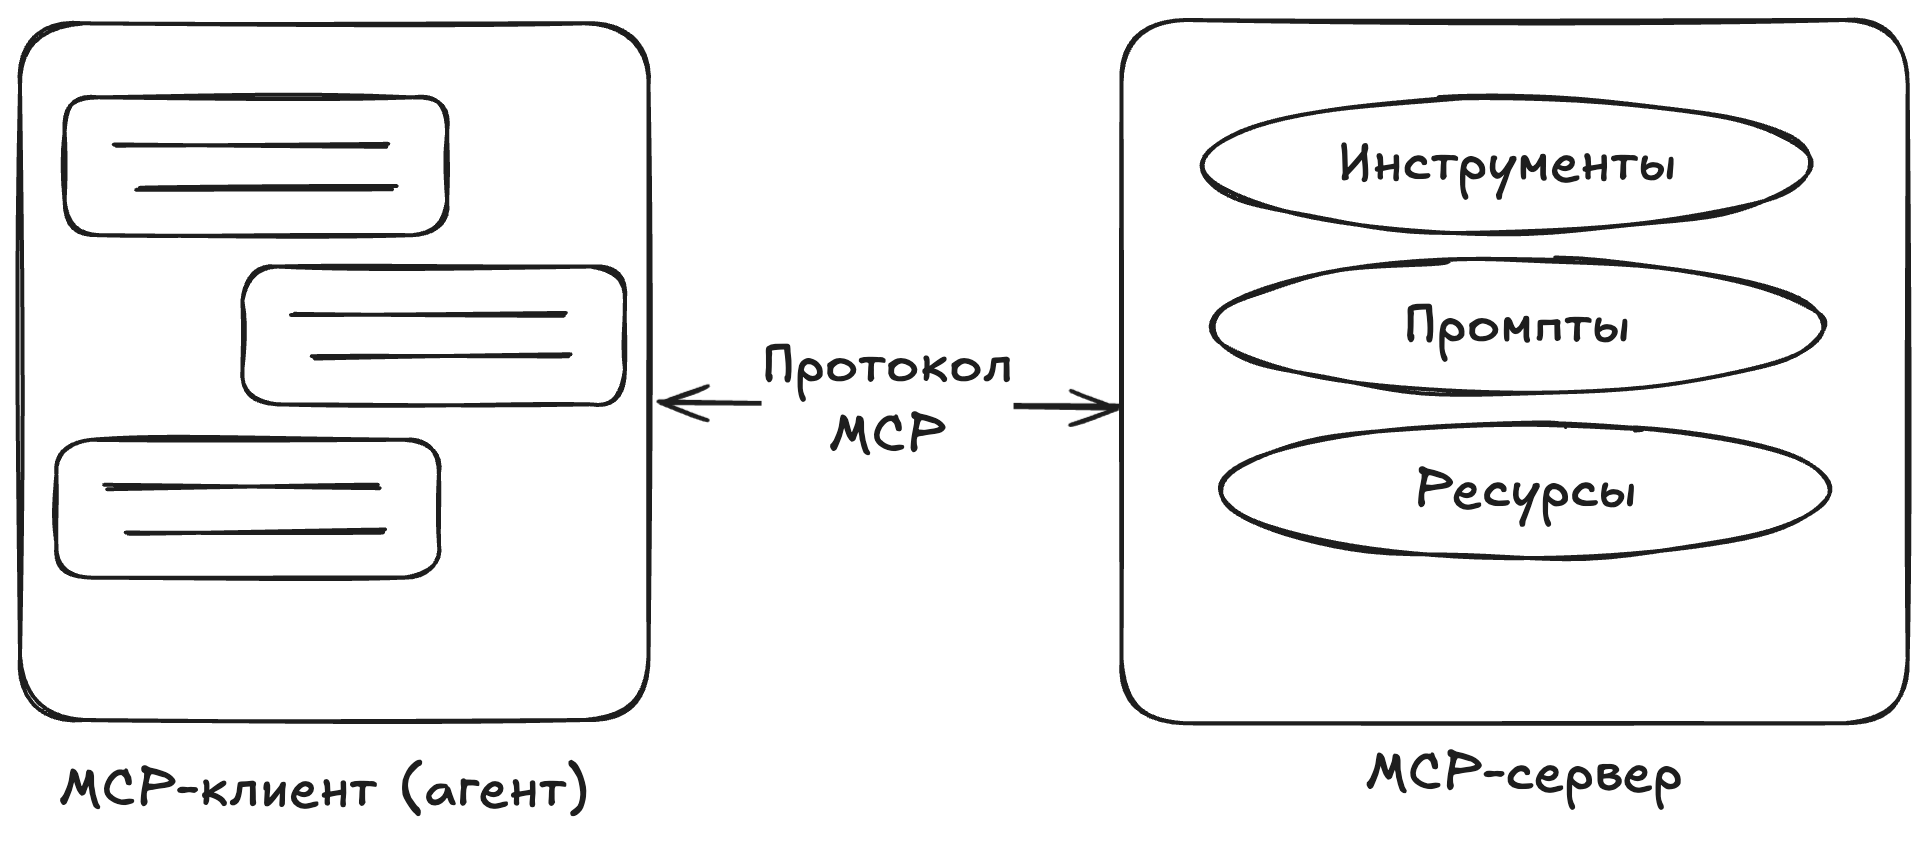

Коротко о ролях и связи:

* **Сервер MCP** — публикует инструменты (имя, описание, схему аргументов) и принимает вызовы; секреты/доступы остаются внутри сервера.
* **Клиент MCP** — подключается к серверу, обнаруживает инструменты и вызывает их; для агента они выглядят «родными».
* **Транспорт** — **канал доставки сообщений** между клиентом и сервером. Используются два варианта:

  * **stdio** — локальный канал stdin/stdout запущенного процесса (удобно для демо);
  * **Streamable HTTP** — длительное двунаправленное HTTP-соединение (подходит для удалённых серверов).
    `stdio` предполагает работу на одной машине; Streamable HTTP можно использовать и локально, и между разными хостами.

В этом мастер-классе мы подключим к клиенту два MCP-сервера по **stdio**:

1. наш сервер с инструментами «погода» и «качество воздуха»;
2. готовый **Time MCP Server** (время и конвертация времени).

### Установка требуемых зависимостей
Чтобы наш ReAct-агент смог работать с инструментами из MCP-серверов, нам понадобится библиотека `langchain-mcp-adapters`. Кроме того, установим быстрый менеджер окружений/пакетов и лаунчер `uv`. Он позволяет запускать готовые Python-MCP-сервера без установки в venv.

На этом мастер-классе мы будем иметь дело только с Python-MCP-серверами, однако на практике встречается большое количество серверов написаны на JavaScript. Там аналогичный запуск делает `npx`. Чтобы команда `npx` заработала, установите Node.js с npm.

In [ ]:
!pip install -q uv langchain-mcp-adapters

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.2/21.2 MB 37.0 MB/s eta 0:00:00


### MCP-сервер
Вынесем логику инструментов в **отдельный процесс** — MCP-сервер. Для этого сохраним код в файл (используем команду `%%writefile`).

С помощью класса `FastMCP` создадим сервер "WeatherAir", с помощью декоратора `@mcp.tool()` поместим в него две функции. Когда файл `weather_air_mcp_server.py` запускается клиентом, MCP-сервер готов общаться с клиентом по stdio.

Единственной особенностью реализации именно в Google Colab стала необходимость отправки сервера в отдельный поток, чтобы они не мешали протоколу MCP.


In [ ]:
%%writefile weather_air_mcp_server.py

from mcp.server.fastmcp import FastMCP
import requests
import sys, logging
logging.basicConfig(stream=sys.stderr, level=logging.WARNING, force=True)


mcp = FastMCP("WeatherAir")

@mcp.tool()
def get_weather(city: str) -> str:
    """Получить текущую погоду для указанного города."""
    url = f"https://wttr.in/{city}?format=j1"
    try:
        data = requests.get(url, timeout=6).json()
        temp_c = data["current_condition"][0]["temp_C"]
        desc   = data["current_condition"][0]["weatherDesc"][0]["value"]
        return f"{desc.lower()}, {temp_c} °C"
    except Exception as e:
        return f"Ошибка: {e}"

@mcp.tool()
def get_air_quality(city: str) -> str:
    """Получить показатели загрязнённости воздуха PM2.5 / PM10."""
    try:
        geo_url = f"https://geocoding-api.open-meteo.com/v1/search?name={city}&count=1"
        geo = requests.get(geo_url, timeout=60).json()
        if not geo.get("results"):
            return "город не найден"

        lat, lon = geo["results"][0]["latitude"], geo["results"][0]["longitude"]

        aq_url = (
            "https://air-quality-api.open-meteo.com/v1/air-quality"
            f"?latitude={lat}&longitude={lon}&hourly=pm10,pm2_5&forecast_days=1"
        )
        aq = requests.get(aq_url, timeout=60).json()
        pm25, pm10 = aq["hourly"]["pm2_5"][0], aq["hourly"]["pm10"][0]
        return f"PM2.5 = {pm25} µg/m³, PM10 = {pm10} µg/m³"
    except Exception as e:
        return f"Ошибка: {e}"

if __name__ == "__main__":
    mcp.run(transport="stdio")


Writing weather_air_mcp_server.py


Поскольку мы  сервер и клиента выносим из ячеек в отдельные файлы, авторизационный ключ от GigaChat API нужно записать в соответствующую переменную окружения.  

In [ ]:
import os
from google.colab import userdata

os.environ["GIGACHAT_CREDENTIALS"] = userdata.get('SBER_AUTH')


### MCP-клиент

Файл клиента представляет собой функцию `main()`, внутри которой содержится конфигурация серверов `servers`. Конфигурация каждого сервера включает в себя его название, транспорт, команду запуска с аргументами, также может включать свои переменные окружения.


Мы запускаем наш самописный сервер погоды и качества воздуха просто командой
```
python weather_air_mcp_server.py
```

 А вот готовый [Time MCP Server](https://pypi.org/project/mcp-server-time/) запускаем через uvx и оборачиваем в bash, чтобы одной строкой задать переменную окружения и перенаправить логи:
```
bash -lc "PYTHONUNBUFFERED=1 uvx mcp-server-time 2>>/content/time_mcp.stderr"
```

* `uvx mcp-server-time` — старт готового Python-сервера без установки в venv;
* `PYTHONUNBUFFERED=1` — немедленный вывод (полезно для `stdio`);
* `2>>/content/time_mcp.stderr` — уводим **stderr** в файл, чтобы не смешивать логи с протоколом MCP, который идёт по **stdout**;
* `bash -lc` — удобный способ выполнить всё одной строкой (env + команда + редирект).

Дальше `MultiServerMCPClient(servers)` сам поднимет процессы, **обнаружит инструменты** (`await client.get_tools()`) и отдаст их агенту как обычные
LangChain-инструменты. Теперь для агента «погода/воздух» и «время» — инструменты одного уровня, хотя они и из разных MCP-серверов.

Также в код клиента добавлено логирование. Благодаря нему мы увидим как будут происходить обращения к GigAChat API.


In [ ]:
фпу

Writing mcp_client.py


### Запуск клиента
Мы описали логику серверов и клиента, осталось только запустить. Выполним команду для запуска `mcp_client.py`.

In [ ]:
!python mcp_client.py

💬 Агент с MCP (погода/воздух + время). Пустая строка = выход.

👤 Вы: дай сводку по Иркутску. Сообщи время, погоду и воздух
[10/10/25 10:31:31] AGENT    HTTP Request: POST https://ngw.devices.sberbank.ru:9443/api/v2/oauth "HTTP/1.1 200 OK"
[10/10/25 10:31:32] AGENT    HTTP Request: POST https://gigachat.devices.sberbank.ru/api/v1/chat/completions "HTTP/1.1 200 OK"
[10/10/25 10:31:34] AGENT    HTTP Request: POST https://gigachat.devices.sberbank.ru/api/v1/chat/completions "HTTP/1.1 200 OK"
[10/10/25 10:31:41] AGENT    HTTP Request: POST https://gigachat.devices.sberbank.ru/api/v1/chat/completions "HTTP/1.1 200 OK"
[10/10/25 10:31:45] AGENT    HTTP Request: POST https://gigachat.devices.sberbank.ru/api/v1/chat/completions "HTTP/1.1 200 OK"
================================ Human Message =================================

дай сводку по Иркутску. Сообщи время, погоду и воздух
================================== Ai Message ==================================
Tool Calls:
  get_current_time (931b


## Что дальше?

На этом наш мастер-класс подходит к концу. Мы прошли путь от одиночного запроса к диалоговому ассистенту, собрали ReAct-агента, добавили память и подключили внешние инструменты через MCP.

* **Посмотрите «большого» агента.** Если хотите увидеть работу с множеством инструментов, субагентами и UI, запустите разработку нашей команды, Универсального агента [**Giga Agent**](https://github.com/ai-forever/giga_agent).
* **Загляните в наш cookbook.** В нём собраны готовые [примеры создания LLM-приложений](https://github.com/ai-forever/gigachain/tree/master/cookbook).
* **Курсы LangChain Academy.** Материалы от разработчиков фреймворков [LangChain и LangGraph](https://academy.langchain.com/).
* **Наши статьи на Хабре.** Мы публикуем [материалы на тему агентов](https://habr.com/ru/search/?target_type=posts&order=relevance&q=[gigachain]).

# Спасибо за участие!




Блокнот мастер-класса доступен по QR-коду:


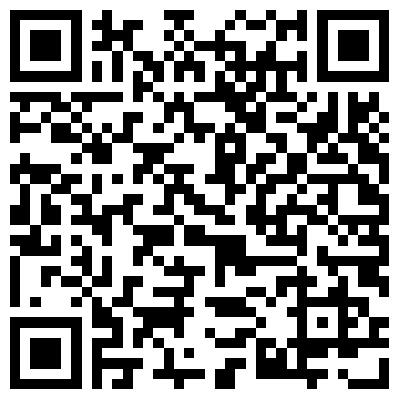

